In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.compose import ColumnTransformer

import os
os.chdir("..")
print(os.getcwd())

df = pd.read_csv("data/processed/cleaned_data.csv")

# Özellikler ve hedef değişkeni ayır
X = df.drop("Churn", axis=1)
y = df["Churn"]

# Train/test split (stratify ile)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Sayısal ve binary sütunları ayır
numeric_features = [col for col in X.columns if X[col].nunique() > 2]

# Sadece numerik sütunlara scaler uygula, diğerlerini dokunmadan geçir
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
    ],
    remainder='passthrough'
)

# Pipeline oluştur
pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('clf', LogisticRegression(solver="lbfgs", max_iter=1000))
])

# Cross validation (örneğin 5-fold)
cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring="f1", n_jobs=-1)

print(f"Cross-validation f1 scores: {cv_scores}")
print(f"Mean CV f1: {cv_scores.mean():.4f}")

# Modeli tüm eğitim verisiyle eğit
pipeline.fit(X_train, y_train)

# Test seti için olasılık tahminleri
y_proba = pipeline.predict_proba(X_test)[:, 1]

# 0.1-0.5 arası farklı threshold değerleri
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5]

for thr in thresholds:
    print("\n" + "=" * 60)
    print(f"Threshold: {thr}")

    y_pred_thr = (y_proba >= thr).astype(int)

    acc = accuracy_score(y_test, y_pred_thr)
    prec = precision_score(y_test, y_pred_thr, pos_label=1, zero_division=0)
    rec = recall_score(y_test, y_pred_thr, pos_label=1, zero_division=0)
    f1_sc = f1_score(y_test, y_pred_thr, pos_label=1, zero_division=0)
    cm = confusion_matrix(y_test, y_pred_thr)

    print(f"Accuracy: {acc:.4f}")
    print(f"Precision (Churn=1): {prec:.4f}")
    print(f"Recall (Churn=1): {rec:.4f}")
    print(f"F1-score (Churn=1): {f1_sc:.4f}")
    print("Confusion matrix (rows=true, cols=pred):")
    print(cm)

c:\Users\ieter\Churn-Prediction\Churn-Prediction-Project
Cross-validation f1 scores: [0.55172414 0.62197393 0.59926471 0.52908068 0.58759124]
Mean CV f1: 0.5779

Threshold: 0.1
Accuracy: 0.5977
Precision (Churn=1): 0.3931
Recall (Churn=1): 0.9439
F1-score (Churn=1): 0.5550
Confusion matrix (rows=true, cols=pred):
[[488 545]
 [ 21 353]]

Threshold: 0.2
Accuracy: 0.6915
Precision (Churn=1): 0.4573
Recall (Churn=1): 0.8583
F1-score (Churn=1): 0.5967
Confusion matrix (rows=true, cols=pred):
[[652 381]
 [ 53 321]]

Threshold: 0.3
Accuracy: 0.7477
Precision (Churn=1): 0.5172
Recall (Churn=1): 0.7647
F1-score (Churn=1): 0.6170
Confusion matrix (rows=true, cols=pred):
[[766 267]
 [ 88 286]]

Threshold: 0.4
Accuracy: 0.7804
Precision (Churn=1): 0.5737
Recall (Churn=1): 0.6765
F1-score (Churn=1): 0.6209
Confusion matrix (rows=true, cols=pred):
[[845 188]
 [121 253]]

Threshold: 0.5
Accuracy: 0.7996
Precision (Churn=1): 0.6447
Recall (Churn=1): 0.5481
F1-score (Churn=1): 0.5925
Confusion matrix (

In [2]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

models = {
    "log_reg": LogisticRegression(solver="lbfgs", max_iter=1000),
    "random_forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=42,
        n_jobs=-1,
    ),
    "xgboost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1,
    ),
}

for name, clf in models.items():
    print("\n" + "=" * 60)
    print(f"Model: {name}")

    pipe = Pipeline([
        ("preprocess", preprocessor),
        ("clf", clf),
    ])

    cv_scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring="f1", n_jobs=-1)
    print(f"CV F1 scores: {cv_scores}")
    print(f"Mean CV F1: {cv_scores.mean():.4f}")

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, pos_label=1)
    rec = recall_score(y_test, y_pred, pos_label=1)
    f1_sc = f1_score(y_test, y_pred, pos_label=1)
    cm = confusion_matrix(y_test, y_pred)

    print(f"Test accuracy: {acc:.4f}")
    print(f"Test precision (Churn=1): {prec:.4f}")
    print(f"Test recall (Churn=1): {rec:.4f}")
    print(f"Test F1 (Churn=1): {f1_sc:.4f}")
    print("Confusion matrix (rows=true, cols=pred):")
    print(cm)



Model: log_reg
CV F1 scores: [0.55172414 0.62197393 0.59926471 0.52908068 0.58759124]
Mean CV F1: 0.5779
Test accuracy: 0.7996
Test precision (Churn=1): 0.6447
Test recall (Churn=1): 0.5481
Test F1 (Churn=1): 0.5925
Confusion matrix (rows=true, cols=pred):
[[920 113]
 [169 205]]

Model: random_forest
CV F1 scores: [0.53107345 0.5530303  0.51396648 0.52398524 0.54339623]
Mean CV F1: 0.5331
Test accuracy: 0.7747
Test precision (Churn=1): 0.5911
Test recall (Churn=1): 0.4947
Test F1 (Churn=1): 0.5386
Confusion matrix (rows=true, cols=pred):
[[905 128]
 [189 185]]

Model: xgboost
CV F1 scores: [0.53308824 0.63023679 0.57913669 0.55350554 0.55172414]
Mean CV F1: 0.5695
Test accuracy: 0.7790
Test precision (Churn=1): 0.5957
Test recall (Churn=1): 0.5241
Test F1 (Churn=1): 0.5576
Confusion matrix (rows=true, cols=pred):
[[900 133]
 [178 196]]


In [3]:
# Logistic Regression - farklı threshold denemeleri

# Mevcut pipeline ve train/test split zaten önceki hücrede tanımlandı.
# Burada sadece test seti için olasılık tahminleri alıp farklı threshold'ları deniyoruz.

# Test seti için olasılık tahminleri
y_proba = pipeline.predict_proba(X_test)[:, 1]

# 0.1-0.5 arası farklı threshold değerleri
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.8, 0.9]

for thr in thresholds:
    print("\n" + "=" * 60)
    print(f"Threshold: {thr}")

    y_pred_thr = (y_proba >= thr).astype(int)

    acc = accuracy_score(y_test, y_pred_thr)
    prec = precision_score(y_test, y_pred_thr, pos_label=1, zero_division=0)
    rec = recall_score(y_test, y_pred_thr, pos_label=1, zero_division=0)
    f1_sc = f1_score(y_test, y_pred_thr, pos_label=1, zero_division=0)
    cm = confusion_matrix(y_test, y_pred_thr)

    print(f"Accuracy: {acc:.4f}")
    print(f"Precision (Churn=1): {prec:.4f}")
    print(f"Recall (Churn=1): {rec:.4f}")
    print(f"F1-score (Churn=1): {f1_sc:.4f}")
    print("Confusion matrix (rows=true, cols=pred):")
    print(cm)


Threshold: 0.1
Accuracy: 0.5977
Precision (Churn=1): 0.3931
Recall (Churn=1): 0.9439
F1-score (Churn=1): 0.5550
Confusion matrix (rows=true, cols=pred):
[[488 545]
 [ 21 353]]

Threshold: 0.2
Accuracy: 0.6915
Precision (Churn=1): 0.4573
Recall (Churn=1): 0.8583
F1-score (Churn=1): 0.5967
Confusion matrix (rows=true, cols=pred):
[[652 381]
 [ 53 321]]

Threshold: 0.3
Accuracy: 0.7477
Precision (Churn=1): 0.5172
Recall (Churn=1): 0.7647
F1-score (Churn=1): 0.6170
Confusion matrix (rows=true, cols=pred):
[[766 267]
 [ 88 286]]

Threshold: 0.4
Accuracy: 0.7804
Precision (Churn=1): 0.5737
Recall (Churn=1): 0.6765
F1-score (Churn=1): 0.6209
Confusion matrix (rows=true, cols=pred):
[[845 188]
 [121 253]]

Threshold: 0.5
Accuracy: 0.7996
Precision (Churn=1): 0.6447
Recall (Churn=1): 0.5481
F1-score (Churn=1): 0.5925
Confusion matrix (rows=true, cols=pred):
[[920 113]
 [169 205]]

Threshold: 0.6
Accuracy: 0.7825
Precision (Churn=1): 0.6619
Recall (Churn=1): 0.3717
F1-score (Churn=1): 0.4760
Co

In [4]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, fbeta_score

# İş problemine en uygun metrik olan F2'yi tanımlıyoruz
# beta=2 demek, Recall'a Precision'dan 2 kat fazla önem ver demektir.
f2_scorer = make_scorer(fbeta_score, beta=2, pos_label=1)

# Lojistik Regresyon Pipeline'ı
pipe_log = Pipeline([
    ("preprocess", preprocessor),
    ("clf", LogisticRegression(solver="lbfgs", max_iter=1000, random_state=42))
])

# Hem regülarizasyon gücünü (C) hem de sınıf ağırlıklarını deniyoruz
# Kampanya maliyeti olduğu için class_weight'i çok uçuk değerler yapmıyoruz
param_grid = {
    'clf__C': [0.01, 0.1, 1, 10], 
    'clf__class_weight': [None, 'balanced', {0: 1, 1: 1.5}, {0: 1, 1: 2}] 
}

# Modeli F2 skoruna göre eğitiyoruz (Eğer kesinlikle F1 olsun dersen scoring="f1" yapabilirsin)
grid_search = GridSearchCV(pipe_log, param_grid, cv=5, scoring=f2_scorer, n_jobs=-1)

print("Arama başlatılıyor...")
grid_search.fit(X_train, y_train)

print(f"En iyi parametreler: {grid_search.best_params_}")

# En iyi modelin test sonuçları
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)

print("\n--- Tuning Sonrası Test Skorları ---")
print(f"Test Recall: {recall_score(y_test, y_pred_tuned, pos_label=1):.4f}")
print(f"Test Precision: {precision_score(y_test, y_pred_tuned, pos_label=1):.4f}")
print(f"Test F1: {f1_score(y_test, y_pred_tuned, pos_label=1):.4f}")
print(f"Test F2: {fbeta_score(y_test, y_pred_tuned, beta=2, pos_label=1):.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_tuned))

Arama başlatılıyor...
En iyi parametreler: {'clf__C': 0.01, 'clf__class_weight': 'balanced'}

--- Tuning Sonrası Test Skorları ---
Test Recall: 0.7914
Test Precision: 0.4876
Test F1: 0.6035
Test F2: 0.7038
Confusion Matrix:
 [[722 311]
 [ 78 296]]


ROC-AUC Skoru: 0.8315


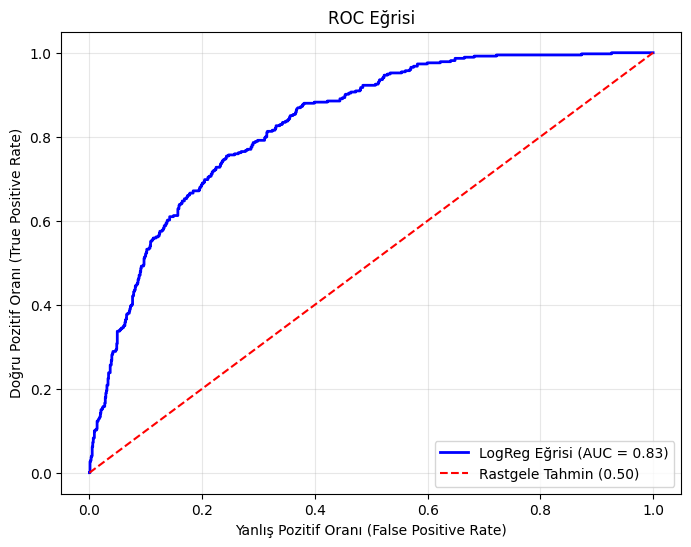

In [5]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# best_model'in daha demin GridSearchCV'den çıktığını varsayıyoruz
# Modelin olasılık tahminlerini alıyoruz (1 sınıfı, yani churn olma olasılıkları)
y_probs = best_model.predict_proba(X_test)[:, 1]

# ROC-AUC skorunu hesaplıyoruz
auc_score = roc_auc_score(y_test, y_probs)
print(f"ROC-AUC Skoru: {auc_score:.4f}")

# Eğri noktalarını hesaplıyoruz
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

# Eğriyi çizdiriyoruz
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', linewidth=2, label=f'LogReg Eğrisi (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Rastgele Tahmin (0.50)')
plt.xlabel('Yanlış Pozitif Oranı (False Positive Rate)')
plt.ylabel('Doğru Pozitif Oranı (True Positive Rate)')
plt.title('ROC Eğrisi')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [6]:
# Logistic Regression - farklı threshold denemeleri

# Mevcut best_model ve train/test split zaten önceki hücrede tanımlandı.
# Burada sadece test seti için olasılık tahminleri alıp farklı threshold'ları deniyoruz.

# Test seti için olasılık tahminleri
y_proba = best_model.predict_proba(X_test)[:, 1]

# 0.1-0.5 arası farklı threshold değerleri
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.8, 0.9]

for thr in thresholds:
    print("\n" + "=" * 60)
    print(f"Threshold: {thr}")

    y_pred_thr = (y_proba >= thr).astype(int)

    acc = accuracy_score(y_test, y_pred_thr)
    prec = precision_score(y_test, y_pred_thr, pos_label=1, zero_division=0)
    rec = recall_score(y_test, y_pred_thr, pos_label=1, zero_division=0)
    f1_sc = f1_score(y_test, y_pred_thr, pos_label=1, zero_division=0)
    cm = confusion_matrix(y_test, y_pred_thr)

    print(f"Accuracy: {acc:.4f}")
    print(f"Precision (Churn=1): {prec:.4f}")
    print(f"Recall (Churn=1): {rec:.4f}")
    print(f"F1-score (Churn=1): {f1_sc:.4f}")
    print("Confusion matrix (rows=true, cols=pred):")
    print(cm)


Threshold: 0.1
Accuracy: 0.4570
Precision (Churn=1): 0.3280
Recall (Churn=1): 0.9947
F1-score (Churn=1): 0.4934
Confusion matrix (rows=true, cols=pred):
[[271 762]
 [  2 372]]

Threshold: 0.2
Accuracy: 0.5529
Precision (Churn=1): 0.3703
Recall (Churn=1): 0.9733
F1-score (Churn=1): 0.5365
Confusion matrix (rows=true, cols=pred):
[[414 619]
 [ 10 364]]

Threshold: 0.3
Accuracy: 0.6041
Precision (Churn=1): 0.3959
Recall (Churn=1): 0.9305
F1-score (Churn=1): 0.5555
Confusion matrix (rows=true, cols=pred):
[[502 531]
 [ 26 348]]

Threshold: 0.4
Accuracy: 0.6660
Precision (Churn=1): 0.4365
Recall (Churn=1): 0.8824
F1-score (Churn=1): 0.5841
Confusion matrix (rows=true, cols=pred):
[[607 426]
 [ 44 330]]

Threshold: 0.5
Accuracy: 0.7235
Precision (Churn=1): 0.4876
Recall (Churn=1): 0.7914
F1-score (Churn=1): 0.6035
Confusion matrix (rows=true, cols=pred):
[[722 311]
 [ 78 296]]

Threshold: 0.6
Accuracy: 0.7669
Precision (Churn=1): 0.5483
Recall (Churn=1): 0.6979
F1-score (Churn=1): 0.6141
Co

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix

# 1. Yeni modelin olasılık tahminlerini alalım
# (best_model'in GridSearchCV'den gelen en iyi Lojistik Regresyon modeli olduğunu varsayıyoruz)
y_probs = best_model.predict_proba(X_test)[:, 1]

# 2. Eşik değerlerini ve boş bir listeyi tanımlayalım
thresholds = np.arange(0.1, 1.0, 0.1)
results_data = []

# 3. Her eşik için Karmaşıklık Matrisi (Confusion Matrix) değerlerini hesaplayalım
for thresh in thresholds:
    # Olasılık eğer eşikten büyükse 1 (Churn), değilse 0 (Kalacak) olsun
    y_pred_thresh = (y_probs >= thresh).astype(int)
    
    # Matrisi oluşturalım (0: Negatif Sınıf, 1: Pozitif Sınıf)
    # ravel() fonksiyonu matrisi TN, FP, FN, TP olarak düzleştirir
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_thresh).ravel()
    
    results_data.append({
        "Threshold": round(thresh, 1),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })

# Veriyi DataFrame'e çevirelim
df_metrics = pd.DataFrame(results_data)

# --- BUNDAN SONRASI SENİN KENDİ YAZDIĞIN KÂR HESAPLAMA KODUYLA AYNI ---

def calculate_net_profit(df, v_cost, c_cost, r_rate, negative_impact_rate=0.0):
    total_churners = df['FN'] + df['TP'] 
    baseline_loss = total_churners * v_cost 

    cost_tp = (df['TP'] * c_cost) + (df['TP'] * (1 - r_rate) * v_cost)
    cost_fp = (df['FP'] * c_cost) + (df['FP'] * negative_impact_rate * v_cost)
    cost_fn = (df['FN'] * v_cost)
    
    total_model_cost = cost_tp + cost_fp + cost_fn
    net_profit = baseline_loss - total_model_cost
    return net_profit

scenarios = {
    "Senaryo 1 (İyimser)": {
        "v_cost": 1000, "c_cost": 50, "r_rate": 0.
        30, "negative_impact_rate": 0.0
    },
    "Senaryo 2 (Kötümser - Gerçekçi)": {
        "v_cost": 500, "c_cost": 100, "r_rate": 0.15, "negative_impact_rate": 0.0
    },
    "Senaryo 3 (Ters Etkili - Uyuyan Dev)": {
        "v_cost": 1000, "c_cost": 50, "r_rate": 0.40, "negative_impact_rate": 0.05
    }
}

comparison_df = df_metrics[['Threshold']].copy()

for name, params in scenarios.items():
    comparison_df[name + " Net Kâr (TL)"] = calculate_net_profit(
        df_metrics, 
        params["v_cost"], 
        params["c_cost"], 
        params["r_rate"], 
        params["negative_impact_rate"]
    )

print("="*80)
print("YENİ MODEL İÇİN FARKLI SENARYOLARA GÖRE THRESHOLD - NET KÂR KARŞILAŞTIRMASI")
print("="*80)
print(comparison_df.to_string(index=False))
print("\n" + "="*80)

for col in comparison_df.columns[1:]:
    best_idx = comparison_df[col].idxmax()
    best_threshold = comparison_df.loc[best_idx, 'Threshold']
    max_profit = comparison_df.loc[best_idx, col]
    print(f"{col} için en optimal eşik: {best_threshold} (Kâr: {max_profit:,.2f} TL)")

YENİ MODEL İÇİN FARKLI SENARYOLARA GÖRE THRESHOLD - NET KÂR KARŞILAŞTIRMASI
 Threshold  Senaryo 1 (İyimser) Net Kâr (TL)  Senaryo 2 (Kötümser - Gerçekçi) Net Kâr (TL)  Senaryo 3 (Ters Etkili - Uyuyan Dev) Net Kâr (TL)
       0.1                           54900.0                                      -85500.0                                            54000.0
       0.2                           60050.0                                      -71000.0                                            65500.0
       0.3                           60450.0                                      -61800.0                                            68700.0
       0.4                           61200.0                                      -50850.0                                            72900.0
       0.5                           58450.0                                      -38500.0                                            72500.0
       0.6                           54500.0                            

ROC-AUC Skoru: 0.8315


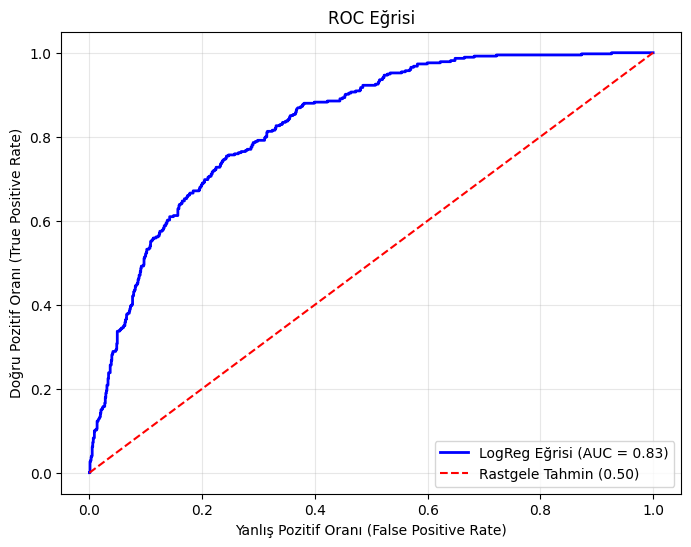

In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# best_model'in daha demin GridSearchCV'den çıktığını varsayıyoruz
# Modelin olasılık tahminlerini alıyoruz (1 sınıfı, yani churn olma olasılıkları)
y_probs = best_model.predict_proba(X_test)[:, 1]

# ROC-AUC skorunu hesaplıyoruz
auc_score = roc_auc_score(y_test, y_probs)
print(f"ROC-AUC Skoru: {auc_score:.4f}")

# Eğri noktalarını hesaplıyoruz
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

# Eğriyi çizdiriyoruz
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', linewidth=2, label=f'LogReg Eğrisi (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Rastgele Tahmin (0.50)')
plt.xlabel('Yanlış Pozitif Oranı (False Positive Rate)')
plt.ylabel('Doğru Pozitif Oranı (True Positive Rate)')
plt.title('ROC Eğrisi')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

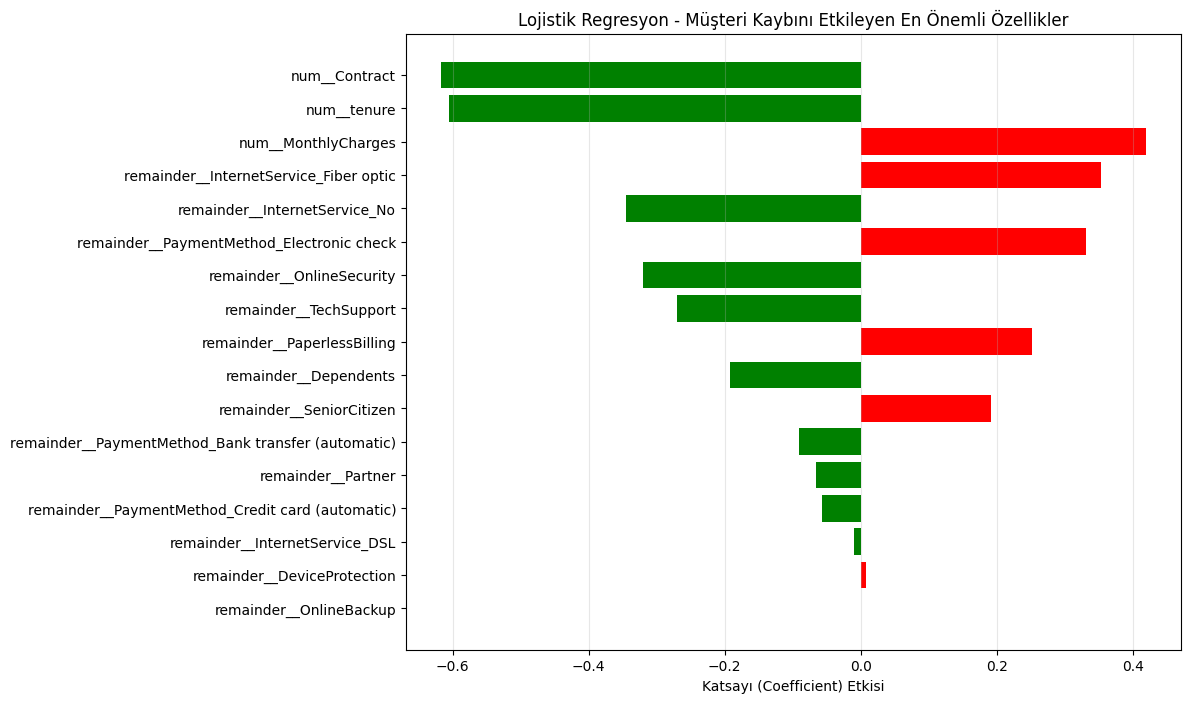

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Pipeline içindeki eğitilmiş modeli ve preprocessor'ı çekelim
log_reg_model = best_model.named_steps['clf']
preprocessor = best_model.named_steps['preprocess']

# 2. İşlenmiş verinin özellik (sütun) isimlerini alalım
# Not: scikit-learn sürümüne göre bu kod çalışır, eğer hata verirse preprocessing adımına göre manuel isim girmek gerekebilir.
feature_names = preprocessor.get_feature_names_out()

# 3. Modelin katsayılarını alalım
coefficients = log_reg_model.coef_[0]

# 4. Katsayıları ve isimleri bir DataFrame'de birleştirip sıralayalım
df_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': coefficients,
    'Absolute_Importance': np.abs(coefficients) # Büyüklüğe göre sıralamak için
}).sort_values(by='Absolute_Importance', ascending=True)

# 5. Görselleştirme (En etkili 20 özelliği çizdirelim)
top_features = df_importance.tail(20)

plt.figure(figsize=(10, 8))
# Renklendirme: Pozitifler kırmızı (Churn tetikleyici), Negatifler yeşil (Elde tutucu)
colors = ['red' if c > 0 else 'green' for c in top_features['Importance']]

plt.barh(top_features['Feature'], top_features['Importance'], color=colors)
plt.xlabel('Katsayı (Coefficient) Etkisi')
plt.title('Lojistik Regresyon - Müşteri Kaybını Etkileyen En Önemli Özellikler')
plt.grid(axis='x', alpha=0.3)
plt.show()

Brier Skoru: 0.1745 (0'a yakın olması iyidir)


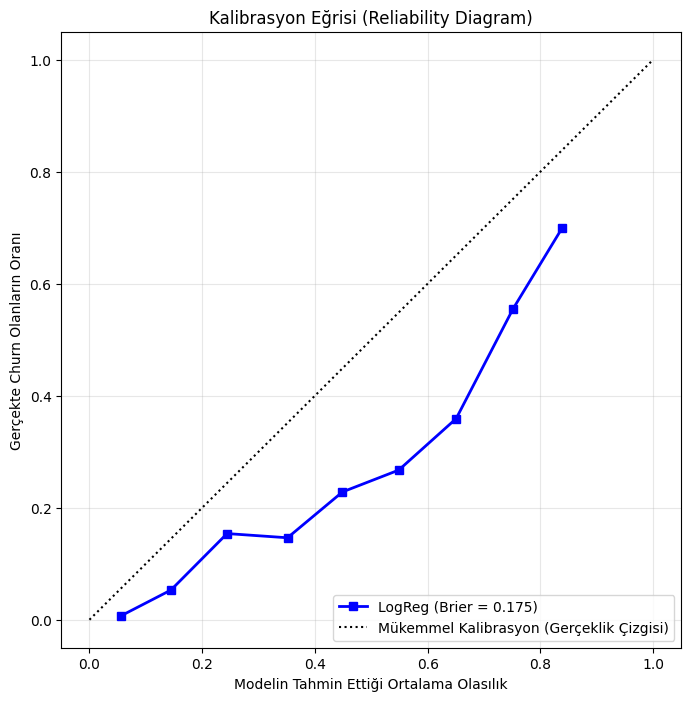

In [10]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

# (best_model'in olasılıklarını bir önceki adımdan y_probs olarak almıştık)
# Eğer silindiyse tekrar hesaplayalım:
y_probs = best_model.predict_proba(X_test)[:, 1]

# 1. Brier Skorunu Hesapla (0 mükemmel, 1 en kötü)
brier_score = brier_score_loss(y_test, y_probs)
print(f"Brier Skoru: {brier_score:.4f} (0'a yakın olması iyidir)")

# 2. Kalibrasyon Eğrisi Değerlerini Hesapla (Olasılıkları 10 gruba/bin'e böler)
fraction_of_positives, mean_predicted_value = calibration_curve(y_test, y_probs, n_bins=10)

# 3. Eğriyi Çizdir
plt.figure(figsize=(8, 8))
plt.plot(mean_predicted_value, fraction_of_positives, "s-", color="blue", linewidth=2, label=f"LogReg (Brier = {brier_score:.3f})")
plt.plot([0, 1], [0, 1], "k:", label="Mükemmel Kalibrasyon (Gerçeklik Çizgisi)")

plt.xlabel("Modelin Tahmin Ettiği Ortalama Olasılık")
plt.ylabel("Gerçekte Churn Olanların Oranı")
plt.title("Kalibrasyon Eğrisi (Reliability Diagram)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [11]:
from sklearn.calibration import CalibratedClassifierCV

# 1. Mevcut en iyi modelini alıp kalibratörün içine koyuyoruz
# method='isotonic' (Lojistik regresyon ve dengesiz veriler için genelde iyi çalışır)
calibrated_model = CalibratedClassifierCV(best_model, method='isotonic', cv=5)

# 2. Modeli eğitim verisiyle tekrar eğitiyoruz (Çok kısa sürer)
calibrated_model.fit(X_train, y_train)

# 3. Artık test seti için "dürüst" ve ütülenmiş olasılıkları alıyoruz
y_probs_calibrated = calibrated_model.predict_proba(X_test)[:, 1]

print("Model kalibrasyonu tamamlandı. Olasılıklar artık gerçek yüzdeleri yansıtıyor.")

Model kalibrasyonu tamamlandı. Olasılıklar artık gerçek yüzdeleri yansıtıyor.
